In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


Churn Distribution:
Churn
0    447
1     53
Name: count, dtype: int64

Churn Rate: 10.60%


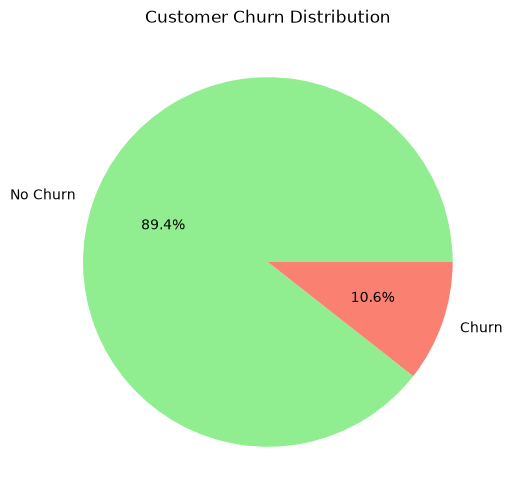

In [3]:
# Overall churn distribution
churn_counts = df['Churn'].value_counts()
print("Churn Distribution:")
print(churn_counts)
print(f"\nChurn Rate: {(df['Churn'].mean()*100):.2f}%")

plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
        colors=['lightgreen', 'salmon'])
plt.title('Customer Churn Distribution')
plt.savefig('../visualizations/churn_distribution.png')
plt.show()

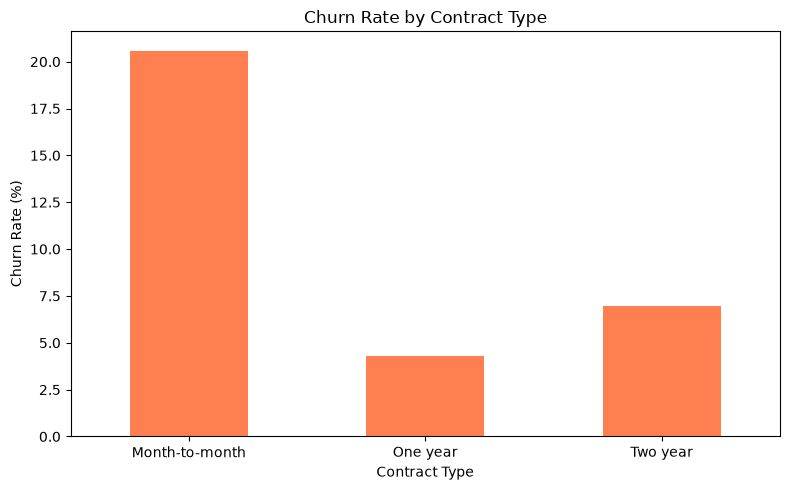

Contract
Month-to-month    20.588235
One year           4.301075
Two year           6.944444
Name: Churn, dtype: float64


In [4]:
# Churn rate by contract type
churn_by_contract = df.groupby('Contract')['Churn'].mean() * 100

plt.figure(figsize=(8, 5))
churn_by_contract.plot(kind='bar', color='coral')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../visualizations/churn_by_contract.png')
plt.show()

print(churn_by_contract)

C:\Users\AA\AppData\Local\Temp\ipykernel_15652\3505437823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=df, palette=['lightgreen', 'salmon'])


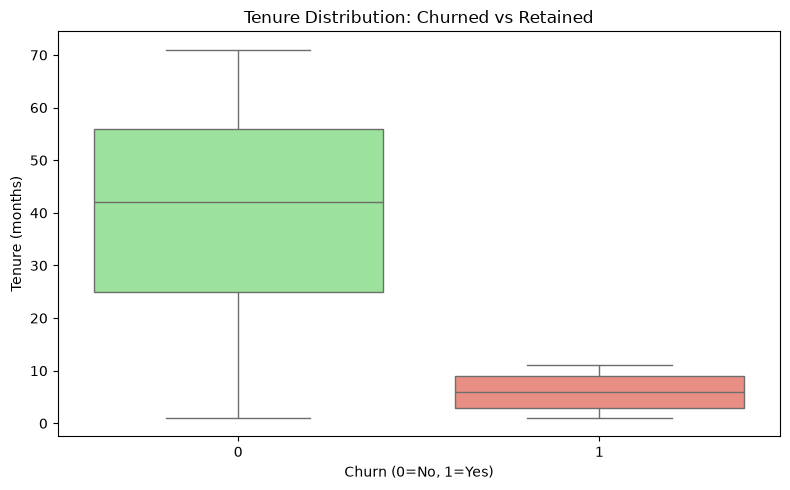

Average Tenure - Churned: 6.0
Average Tenure - Retained: 40.15212527964206


In [5]:
# Tenure comparison: churned vs retained customers
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Tenure', data=df, palette=['lightgreen', 'salmon'])
plt.title('Tenure Distribution: Churned vs Retained')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (months)')
plt.tight_layout()
plt.savefig('../visualizations/tenure_churn.png')
plt.show()

print("Average Tenure - Churned:", df[df['Churn']==1]['Tenure'].mean())
print("Average Tenure - Retained:", df[df['Churn']==0]['Tenure'].mean())

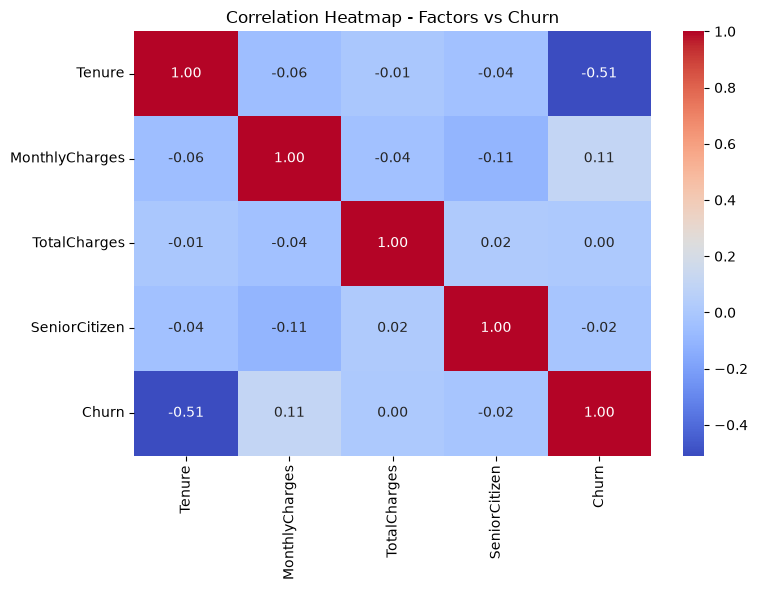

In [6]:
# Correlation between numeric factors and churn
numeric_cols = df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']]
correlation = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Factors vs Churn')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png')
plt.show()

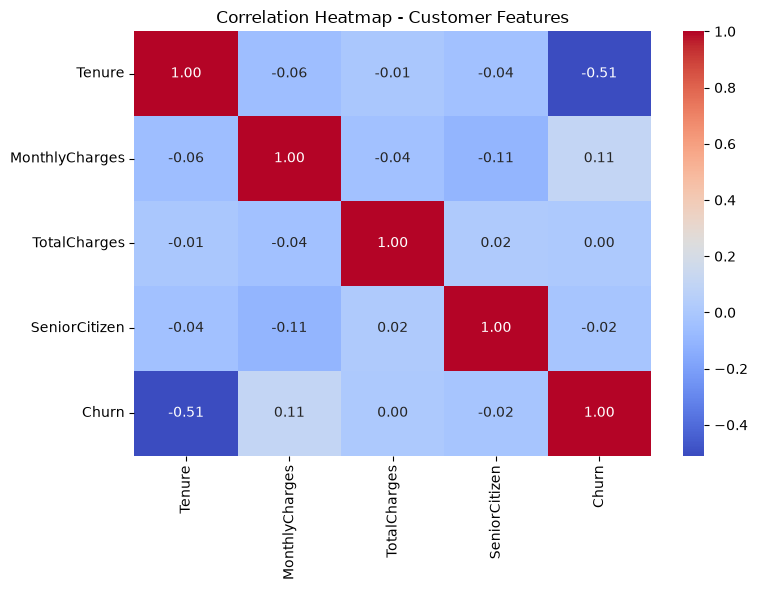

In [7]:
# Correlation between numerical features
numeric_cols = df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']]
correlation = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Customer Features')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png')
plt.show()

In [8]:
from scipy import stats

churned_tenure = df[df['Churn']==1]['Tenure']
retained_tenure = df[df['Churn']==0]['Tenure']

t_stat, p_value = stats.ttest_ind(churned_tenure, retained_tenure)

print("--- T-TEST: Tenure (Churned vs Retained) ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: SIGNIFICANT difference in tenure (p < 0.05)")
else:
    print("Result: NO significant difference")

--- T-TEST: Tenure (Churned vs Retained) ---
T-Statistic: -13.2034
P-Value: 0.000000
Result: SIGNIFICANT difference in tenure (p < 0.05)


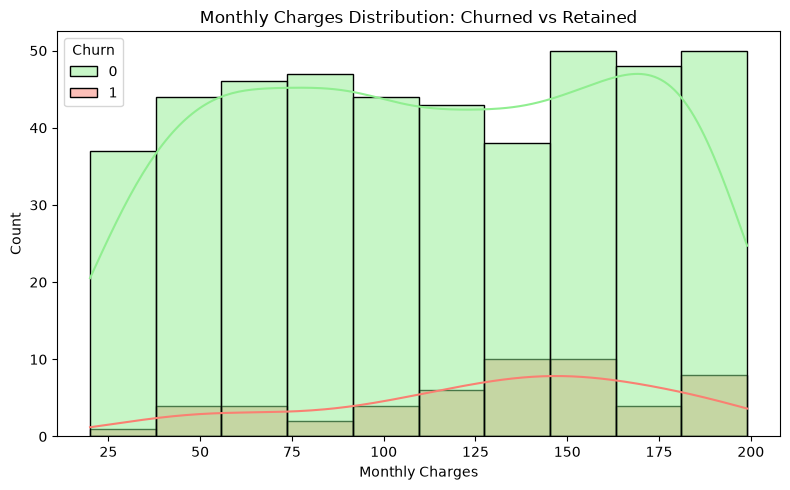

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette=['lightgreen', 'salmon'])
plt.title('Monthly Charges Distribution: Churned vs Retained')
plt.xlabel('Monthly Charges')
plt.tight_layout()
plt.savefig('../visualizations/charges_distribution.png')
plt.show()